# Edge Detection Using OpenCV and Sobel Kernels

This notebook applies predefined Sobel kernels to `cat.png` using OpenCV convolution. It detects vertical edges, horizontal edges, and their combined gradient magnitude.

In [1]:
%pip install opencv-python matplotlib



```python
%pip install opencv-python matplotlib
```

In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

INPUT_IMAGE = Path("cat.png")
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

if not INPUT_IMAGE.exists():
    raise FileNotFoundError(f"Could not find {INPUT_IMAGE.resolve()}. Run this notebook from its folder.")

## 1. Load and prepare the image

OpenCV loads colour images in BGR channel order. For edge detection, the image is converted to a single grayscale channel; this lets each kernel measure only changes in brightness.

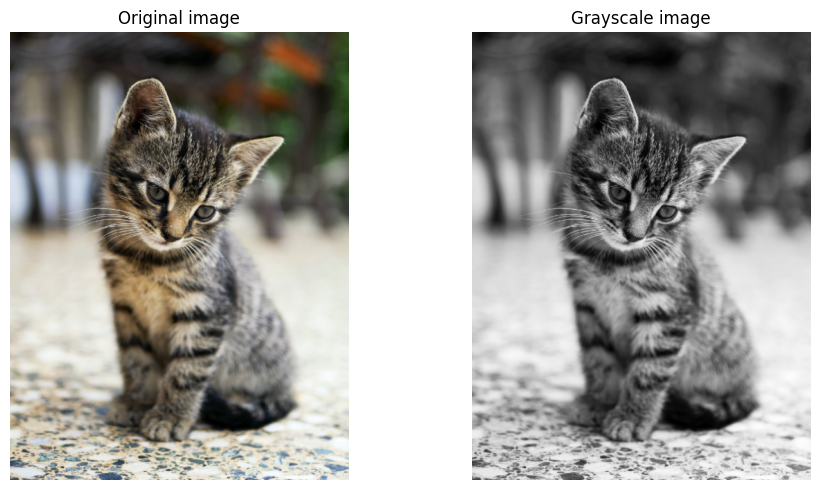

In [4]:
image_bgr = cv2.imread(str(INPUT_IMAGE), cv2.IMREAD_COLOR)


image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_rgb)
axes[0].set_title("Original image")
axes[1].imshow(gray_image, cmap="gray")
axes[1].set_title("Grayscale image")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 2. Apply Sobel kernels with OpenCV convolution



In [5]:
# Predefined 3x3 Sobel kernels.
SOBEL_X = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

SOBEL_Y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)

gradient_x = cv2.filter2D(gray_image, ddepth=cv2.CV_32F, kernel=SOBEL_X)
gradient_y = cv2.filter2D(gray_image, ddepth=cv2.CV_32F, kernel=SOBEL_Y)

# Absolute values make edges visible regardless of whether they are dark-to-light or light-to-dark.
vertical_edges = cv2.convertScaleAbs(gradient_x)
horizontal_edges = cv2.convertScaleAbs(gradient_y)

# Combine both directional responses: sqrt(Gx^2 + Gy^2).
edge_magnitude = cv2.magnitude(gradient_x, gradient_y)
combined_edges = cv2.normalize(edge_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

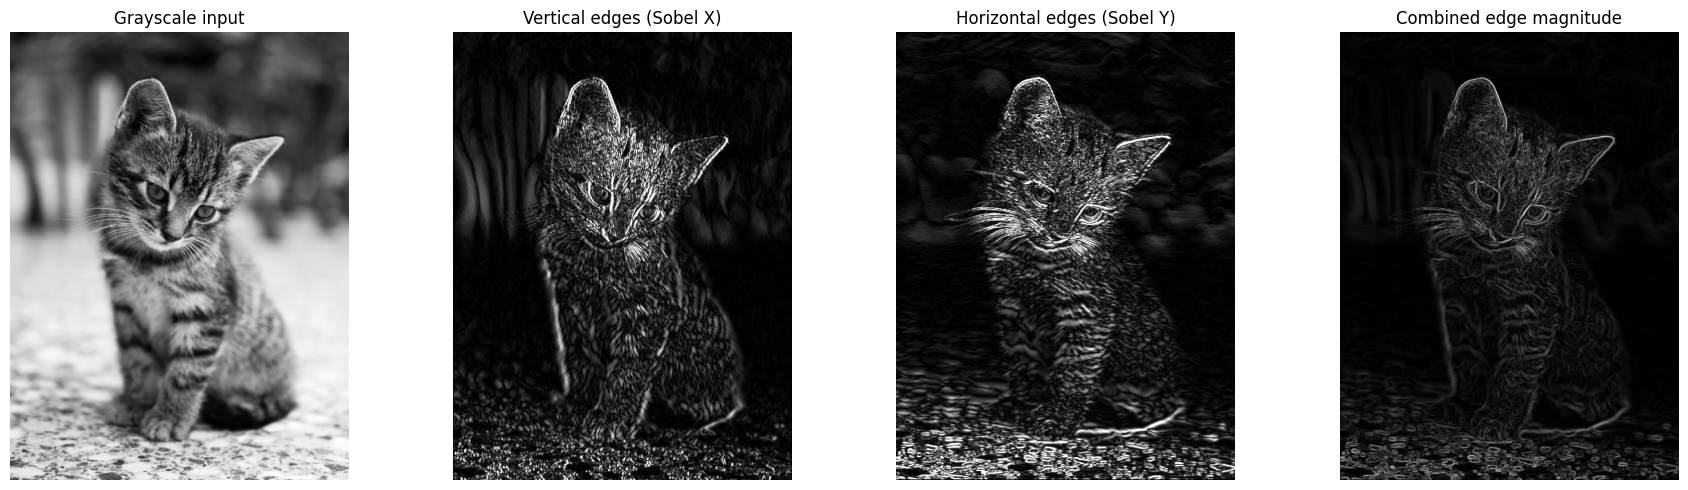

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

result_images = [gray_image, vertical_edges, horizontal_edges, combined_edges]
titles = [
    "Grayscale input",
    "Vertical edges (Sobel X)",
    "Horizontal edges (Sobel Y)",
    "Combined edge magnitude",
]

for axis, result, title in zip(axes, result_images, titles):
    axis.imshow(result, cmap="gray")
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()

## 3. Threshold and save the results

The combined response contains the strength of each edge. Thresholding retains stronger edges and removes weak responses. Increase `THRESHOLD` for a cleaner edge map or decrease it to keep more detail.

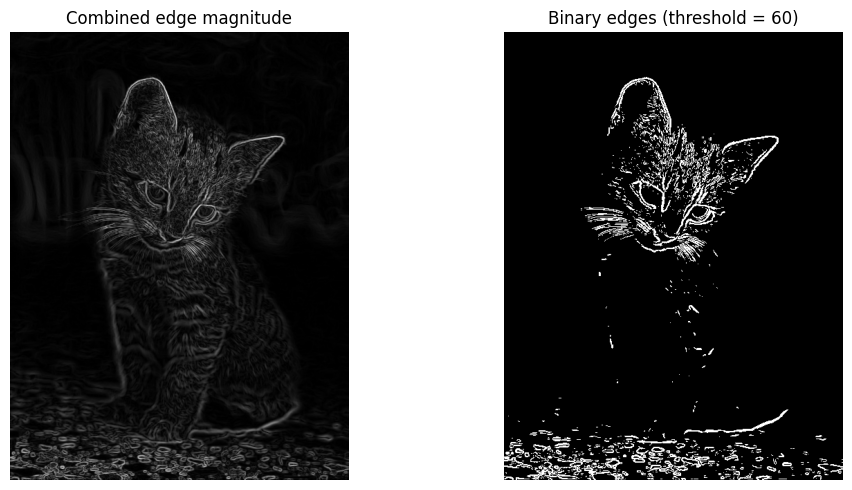

Saved all edge maps to: /content/results


In [7]:
THRESHOLD = 60
_, binary_edges = cv2.threshold(combined_edges, THRESHOLD, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(combined_edges, cmap="gray")
axes[0].set_title("Combined edge magnitude")
axes[1].imshow(binary_edges, cmap="gray")
axes[1].set_title(f"Binary edges (threshold = {THRESHOLD})")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR / "vertical_edges.png"), vertical_edges)
cv2.imwrite(str(OUTPUT_DIR / "horizontal_edges.png"), horizontal_edges)
cv2.imwrite(str(OUTPUT_DIR / "combined_edges.png"), combined_edges)
cv2.imwrite(str(OUTPUT_DIR / "binary_edges.png"), binary_edges)



## Conclusion

Sobel X and Sobel Y isolate edges in perpendicular directions. Combining their responses provides a more complete edge map of the cat image. The thresholded result is useful when only prominent boundaries are required.